# India Air Quality Analysis & Prediction

## 1. Project Overview


## 2. Dataset

In [11]:
import pandas as pd
import os

df = pd.read_csv(os.path.join('air_quality_index_dataset', 'city_day.csv'))
print(df.head(5))
print(df.shape)

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
(29531, 16)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [7]:
print(df.describe())

              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.820000     56.255000      5.630000     11.750000     12.820000   
50%       48.570000     95.680000      9.890000     21.690000     23.520000   
75%       80.590000    149.745000     19.950000     37.620000     40.127500   
max      949.990000   1000.000000    390.680000    362.210000    467.630000   

                NH3            CO           SO2            O3       Benzene  \
count  19203.000000  27472.000000  25677.000000  25509.000000  23908.000000   
mean      23.483476      2.248598     14.531977     34.491430      3.280840   
std       25.684275      6.962884     18.133775    

### Initial Observations

The dataset contains **29,531 records across 16 columns**, including city, date, pollutant concentrations, AQI, and AQI bucket.

Initial inspection shows that:
- `City` contains no missing values and can be used to identify locations.
- `Date` contains no missing values but is currently stored as a string and will need to be converted to datetime for time-based analysis.
- Several pollutant measurements contain missing values, with `PM10`, `NH3`, and `Xylene` having substantial gaps.
- The dataset contains both numerical pollutant measurements and categorical variables such as `City` and `AQI_Bucket`.
- `AQI` has **24,850 non-null observations**, leaving 4,681 records without an AQI value.
- The pollutant variables show considerable variation in their distributions. For example, `PM2.5` has a median of **48.57** compared with a maximum of **949.99**, while AQI has a median of **118** and a maximum of **2,049**.
- The large differences between median and maximum values suggest the presence of **extreme observations (outliers)**, which should be considered during exploratory analysis and modeling.


These observations will guide the data-cleaning and preprocessing steps in the next section.

## 3. Data Cleaning & Preprocessing

In [8]:
# Selecting columns to use 
cols_to_use = ['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'AQI', 'AQI_Bucket']
df_extracted = df[cols_to_use].copy()
print(df_extracted.head())


        City        Date  PM2.5  PM10    NO2  AQI AQI_Bucket
0  Ahmedabad  2015-01-01    NaN   NaN  18.22  NaN        NaN
1  Ahmedabad  2015-01-02    NaN   NaN  15.69  NaN        NaN
2  Ahmedabad  2015-01-03    NaN   NaN  19.30  NaN        NaN
3  Ahmedabad  2015-01-04    NaN   NaN  18.48  NaN        NaN
4  Ahmedabad  2015-01-05    NaN   NaN  21.42  NaN        NaN


In [12]:
# Handling Nulls
print(df_extracted.isnull().sum())

# Dropping rows where AQI is Null
df_extracted = df_extracted.dropna(subset = ['AQI'])
print(df_extracted.isnull().sum())
print(df_extracted.shape)

# Filling missing values of PM2.5 with its mean
df_extracted['PM2.5'] = df_extracted['PM2.5'].fillna(df_extracted['PM2.5'].mean())
print(df_extracted.isnull().sum())
print(df_extracted.shape)


City             0
Date             0
PM2.5          678
PM10          7086
NO2            391
AQI              0
AQI_Bucket       0
dtype: int64
City             0
Date             0
PM2.5          678
PM10          7086
NO2            391
AQI              0
AQI_Bucket       0
dtype: int64
(24850, 7)
City             0
Date             0
PM2.5            0
PM10          7086
NO2            391
AQI              0
AQI_Bucket       0
dtype: int64
(24850, 7)


In [13]:
# Sorting
print(df_extracted.sort_values(by = ['City', 'AQI'], ascending = [True, False]))

            City        Date       PM2.5   PM10     NO2     AQI AQI_Bucket
1145   Ahmedabad  2018-02-19  242.660000    NaN  199.17  2049.0     Severe
1136   Ahmedabad  2018-02-10  185.770000    NaN  172.84  1917.0     Severe
560    Ahmedabad  2016-07-14   38.130000    NaN   48.06  1842.0     Severe
1048   Ahmedabad  2017-11-14  207.190000    NaN  146.18  1747.0     Severe
1463   Ahmedabad  2019-01-03  131.500000    NaN   75.82  1719.0     Severe
...          ...         ...         ...    ...     ...     ...        ...
26330    Talcher  2018-10-14   67.476613   0.13   70.90    15.0       Good
25991   Shillong  2020-05-22    8.580000  12.38    2.84    14.0       Good
26308    Talcher  2018-09-22   67.476613   0.04   31.52    14.0       Good
25810   Shillong  2019-11-23    6.560000   8.70    0.95    14.0       Good
26329    Talcher  2018-10-13   67.476613   0.07   51.49    13.0       Good

[24850 rows x 7 columns]
                City        Date       PM2.5   PM10     NO2     AQI AQI_Bu

In [14]:
# Aggregating
print(df_extracted.groupby('City')['AQI'].mean().round(2))

City
Ahmedabad             452.12
Aizawl                 34.77
Amaravati              95.30
Amritsar              119.92
Bengaluru              94.32
Bhopal                132.83
Brajrajnagar          150.28
Chandigarh             96.50
Chennai               114.50
Coimbatore             73.02
Delhi                 259.49
Ernakulam              92.36
Gurugram              225.12
Guwahati              140.11
Hyderabad             109.21
Jaipur                133.68
Jorapokhar            159.25
Kochi                 104.28
Kolkata               140.57
Lucknow               217.97
Mumbai                105.35
Patna                 240.78
Shillong               53.80
Talcher               172.89
Thiruvananthapuram     75.88
Visakhapatnam         117.27
Name: AQI, dtype: float64


In [15]:
print(df_extracted.groupby('AQI_Bucket').size())

AQI_Bucket
Good            1341
Moderate        8829
Poor            2781
Satisfactory    8224
Severe          1338
Very Poor       2337
dtype: int64


### Aggregation Insights

The AQI distribution shows that **Moderate** and **Satisfactory** readings make up the majority of observations, while **Very Poor** and **Severe** readings represent a substantial portion of the dataset.

At the city level, the mean AQI varies considerably across locations, with **Ahmedabad showing the highest mean AQI** and **Aizwal the lowest** in this dataset.

These differences motivate further analysis of AQI patterns by category and season.

### AQI Categorization

The dataset includes an `AQI_Bucket` column containing categorical AQI labels, but the numerical boundaries corresponding to these categories are not explicitly defined in the dataset.

To enable analysis using the numerical `AQI` values, we create a separate categorical variable by dividing AQI into defined ranges. These ranges will allow us to examine the distribution of air-quality conditions more systematically.

In [16]:
bins = [0, 50, 100, 200, 300, 500]
label_names = ["Good", "Moderate", "Poor", "Very Poor", "Severe"]
df_extracted_cut = pd.cut(df_extracted['AQI'], bins, labels = label_names)
print(df_extracted_cut.value_counts())


AQI
Poor         8829
Moderate     8224
Severe       3132
Very Poor    2781
Good         1341
Name: count, dtype: int64


### Comparing Derived and Original AQI Categories

The derived categories were compared with the original `AQI_Bucket` column to understand how the chosen numerical boundaries affect the results.

The comparison revealed important differences:

- The original `AQI_Bucket` contains **six categories**, including `Satisfactory`, while the custom categorization initially used five categories.
- As a result, observations that would fall into the `Satisfactory` range were grouped into `Moderate` in the custom categorization.
- The `Severe` category also differs substantially between the two approaches because the selected numerical boundaries cover a different AQI range.
- This demonstrates that **AQI category counts depend directly on the numerical boundaries chosen for each bin**.

For this analysis, the original `AQI_Bucket` is therefore retained as the source categorical variable, while the custom categorization is treated as a derived feature for analysis.

### Seasonal Classification

The date information is used (after converting to datetime and extracting months) to assign each observation to a season. This allows us to investigate whether air-quality conditions vary systematically across different seasons.

In [19]:
df_extracted['Date'] = pd.to_datetime(df_extracted['Date'], errors = 'coerce')
df_extracted['month_num'] = df_extracted['Date'].dt.month
print(df_extracted.head())

         City       Date   PM2.5  PM10    NO2    AQI AQI_Bucket  month_num  \
28  Ahmedabad 2015-01-29   83.13   NaN  28.71  209.0       Poor          1   
29  Ahmedabad 2015-01-30   79.84   NaN  28.68  328.0  Very Poor          1   
30  Ahmedabad 2015-01-31   94.52   NaN  32.66  514.0     Severe          1   
31  Ahmedabad 2015-02-01  135.99   NaN  42.08  782.0     Severe          2   
32  Ahmedabad 2015-02-02  178.33   NaN  35.31  914.0     Severe          2   

    Season  
28  Winter  
29  Winter  
30  Winter  
31  Winter  
32  Winter  


In [20]:
# Now mapping month numbers to seasons:
seasons_by_month = {
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Summer", 4: "Summer", 5: "Summer",
    6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Post-Monsoon", 11: "Post-Monsoon"
}
df_extracted['Season'] = df_extracted['month_num'].map(seasons_by_month)
print(df_extracted.head())
print(df_extracted.shape)

         City       Date   PM2.5  PM10    NO2    AQI AQI_Bucket  month_num  \
28  Ahmedabad 2015-01-29   83.13   NaN  28.71  209.0       Poor          1   
29  Ahmedabad 2015-01-30   79.84   NaN  28.68  328.0  Very Poor          1   
30  Ahmedabad 2015-01-31   94.52   NaN  32.66  514.0     Severe          1   
31  Ahmedabad 2015-02-01  135.99   NaN  42.08  782.0     Severe          2   
32  Ahmedabad 2015-02-02  178.33   NaN  35.31  914.0     Severe          2   

    Season  
28  Winter  
29  Winter  
30  Winter  
31  Winter  
32  Winter  
(24850, 9)


In [21]:
# Seasonal AQI Variation
df_seasonal = df_extracted.groupby('Season')['AQI'].mean().round(2)
print(df_seasonal)
print(df_seasonal.shape)


Season
Monsoon         115.56
Post-Monsoon    215.47
Summer          147.67
Winter          220.61
Name: AQI, dtype: float64
(4,)


### Seasonal AQI Patterns

The mean AQI varies substantially across seasons:

- **Winter:** 220.61
- **Post-Monsoon:** 215.47
- **Summer:** 147.67
- **Monsoon:** 115.56

Winter and post-monsoon periods show the highest mean AQI, while monsoon has the lowest mean AQI in this dataset.

This seasonal variation suggests that temporal and environmental factors may be relevant when analyzing air-quality patterns. Further analysis would be required to determine which specific climate variables contribute to these differences.

### Saving the Cleaned Dataset

The cleaned dataset is saved for use in the subsequent exploratory analysis and modeling stages.

In [22]:
df_extracted.to_csv("data/aqi_cleaned.csv", index=False)

## 4. Exploratory Data Analysis

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the cleaned data as df
df = pd.read_csv("data/aqi_cleaned.csv")
print(df.head())
print("DataFrame shape: ", df.shape)


        City        Date   PM2.5  PM10    NO2    AQI AQI_Bucket  month_num  \
0  Ahmedabad  2015-01-29   83.13   NaN  28.71  209.0       Poor          1   
1  Ahmedabad  2015-01-30   79.84   NaN  28.68  328.0  Very Poor          1   
2  Ahmedabad  2015-01-31   94.52   NaN  32.66  514.0     Severe          1   
3  Ahmedabad  2015-02-01  135.99   NaN  42.08  782.0     Severe          2   
4  Ahmedabad  2015-02-02  178.33   NaN  35.31  914.0     Severe          2   

   Season  
0  Winter  
1  Winter  
2  Winter  
3  Winter  
4  Winter  
DataFrame shape:  (24850, 9)


### AQI Over Time: Delhi

To examine temporal patterns in air quality, the `Date` column is converted to datetime and the AQI measurements for Delhi are plotted chronologically from 2015 to 2020.

8840   2015-01-01
8841   2015-01-02
8842   2015-01-03
8843   2015-01-04
8844   2015-01-05
Name: Date, dtype: datetime64[ns]
datetime64[ns]


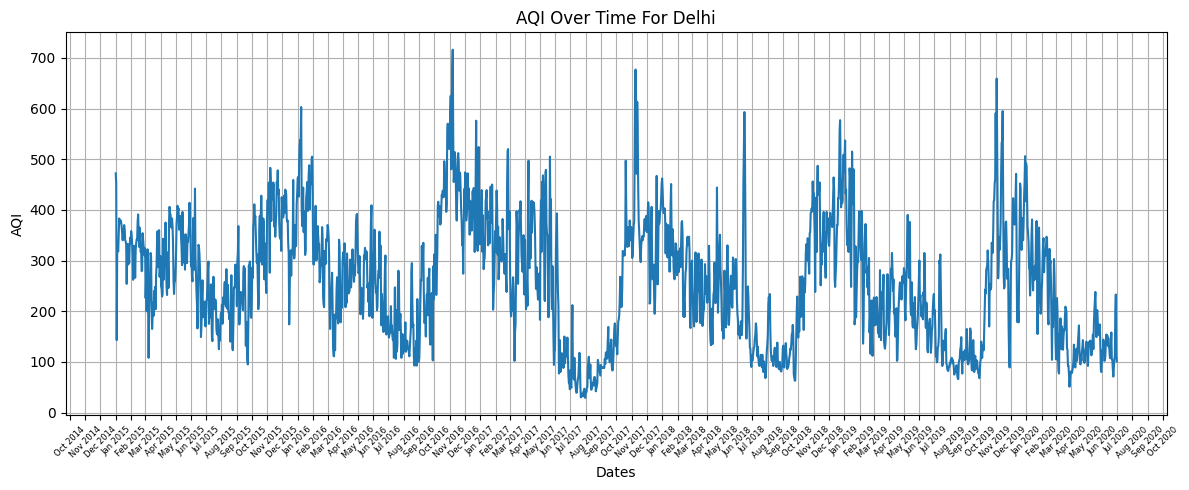

In [25]:
import matplotlib.dates as mdates
df['Date'] = pd.to_datetime(df['Date'])

delhi = df[df['City'] == 'Delhi'].sort_values('Date')
print(delhi['Date'].head())
print(delhi['Date'].dtype)

plt.figure(figsize = (12,5))
plt.plot(delhi['Date'], delhi['AQI'])

plt.title("AQI Over Time For Delhi")
plt.xlabel("Dates")
plt.ylabel("AQI")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation = 45, fontsize = 6)
plt.grid(True)
plt.tight_layout()
plt.show()




**Observation:** AQI shows a recurring seasonal pattern, with higher values generally occurring during winter and lower values during the monsoon period. The plot also shows substantial short-term variation within individual seasons.

### Distribution of AQI

A histogram is used to examine the distribution and spread of AQI values across the dataset.

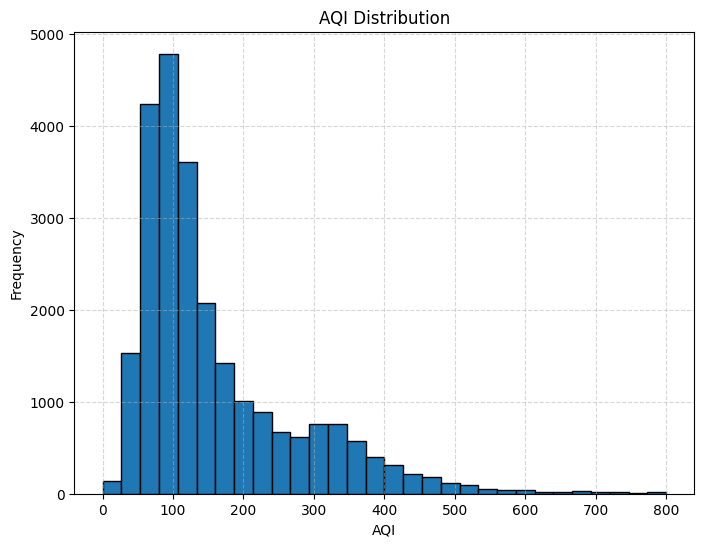

In [26]:
plt.figure(figsize = (8,6))
plt.hist(df['AQI'], bins = 30, edgecolor = 'black', range = (0,800))

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.show()



**Observation:** AQI is right-skewed, with most observations concentrated at lower values, centered around 100 and a long tail extending toward very high AQI values. The wide range indicates substantial variation in air-quality conditions across the dataset.

### AQI by Season

The distribution of AQI across seasons is compared using boxplots. This allows differences in central tendency, spread, and extreme observations to be examined.

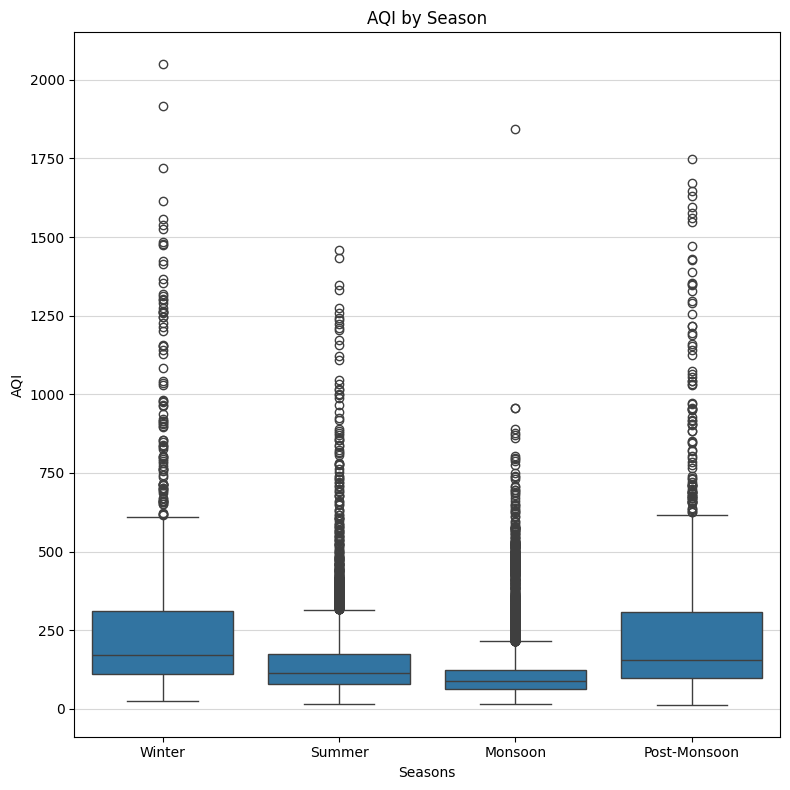

In [28]:
plt.figure(figsize = (8,8))
sns.boxplot(
    data = df,
    x = 'Season',
    y = 'AQI'
)
plt.title("AQI by Season")
plt.xlabel("Seasons")
plt.ylabel("AQI")
# Can add plt.ylim(0,800) but the outliers going up 2000+ are real data points
plt.grid(True, axis = 'y', alpha = 0.5)
plt.tight_layout()
plt.show()


**Observation:** Winter has the highest median AQI (~150) among the seasons, while monsoon has the lowest (~90). Post-monsoon shows relatively high variability, and all seasons contain observations extending to substantially higher AQI values.

### Mean AQI by City

The mean AQI is calculated for each city and the ten cities with the highest mean AQI are visualized.

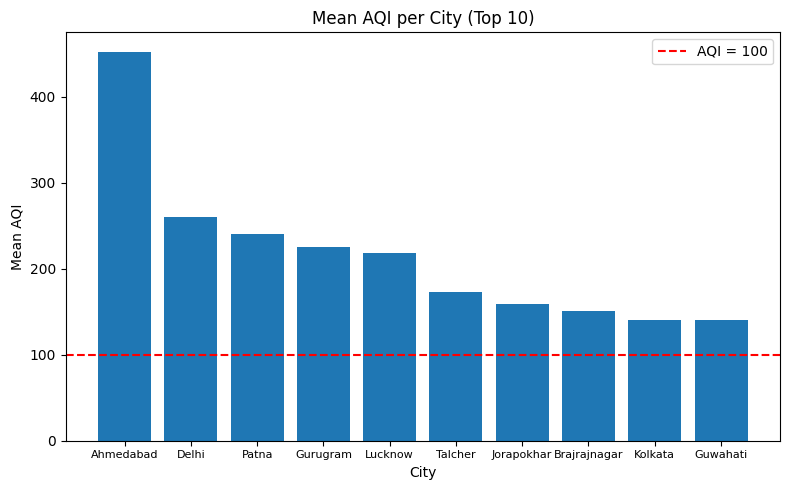

In [30]:
df_top = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize = (8,5))
plt.bar(df_top.index, df_top.values)

plt.title("Mean AQI per City (Top 10)")
plt.xlabel("City")
plt.ylabel("Mean AQI")
plt.xticks(fontsize = 8)

plt.axhline(100, color = 'red', linestyle = '--', label='AQI = 100')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** Ahmedabad has the highest mean AQI among the cities shown, with a substantially higher average than most of the other cities in the top ten. All ten cities have mean AQI values above 100.

### Relationship Between PM2.5 and AQI

A scatter plot with a fitted regression line is used to examine the relationship between PM2.5 concentration and AQI.

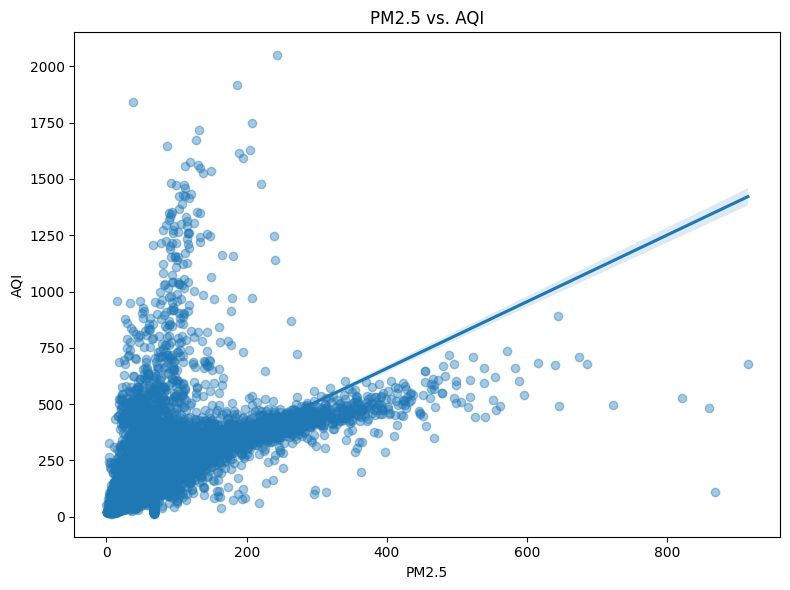

In [31]:
plt.figure(figsize = (8,6))
sns.regplot(
    data = df,
    x = 'PM2.5',
    y = 'AQI',
    scatter_kws = {"alpha": 0.4}
    )

plt.title("PM2.5 vs. AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

**Observation:** PM2.5 and AQI show a positive relationship, with higher PM2.5 values generally associated with higher AQI. However, the spread of AQI values increases at higher PM2.5 levels, indicating substantial variability that may not be captured by a simple linear relationship.The plot is Fan-Shaped (heteroscedasticity) the spread of AQI values gets wider as PM2.5 increases. 

### Correlation Between Pollutants and AQI

Pearson correlation coefficients are calculated for selected pollutant variables and AQI to examine their linear relationships.

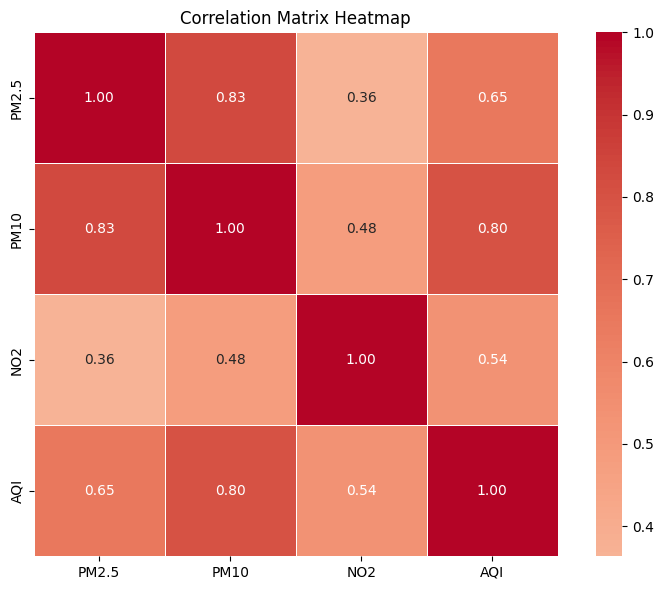

In [32]:
corr_matrix = df[['PM2.5', 'PM10', 'NO2', 'AQI']].corr()

plt.figure(figsize = (8,6))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    center = 0,
    fmt = '.2f',
    linewidths = 0.5,
    square = True
)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

**Observation:** Among the selected pollutants, PM10 has the strongest linear correlation with AQI, followed by PM2.5 and NO2. PM2.5 and PM10 are also strongly correlated with each other, indicating that these pollutant measurements contain related information.

## 5. Data Visualization

### AQI Analysis Dashboard

The following dashboard combines four complementary views of the dataset to provide a concise overview of temporal patterns, AQI distribution, seasonal variation, and the relationship between PM2.5 and AQI.

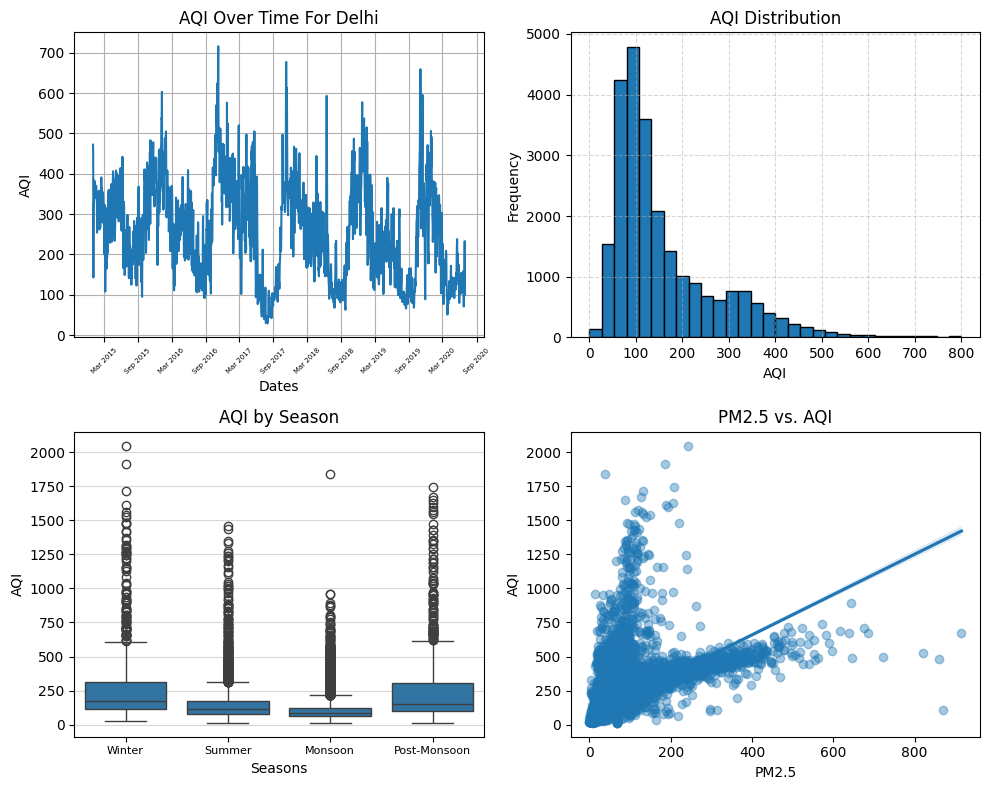

In [33]:
plt.figure(figsize = (10, 8))

# subplot 1 - Delhi AQI Line
plt.subplot(2,2,1)
plt.plot(delhi['Date'], delhi['AQI'])

plt.title("AQI Over Time For Delhi")
plt.xlabel("Dates")
plt.ylabel("AQI")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6)) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation = 45, fontsize = 5)
plt.grid(True)

# subplot 2 - AQI Histogram
plt.subplot(2,2,2)
plt.hist(df['AQI'], bins = 30, edgecolor = 'black', range = (0,800))

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(True, linestyle = '--', alpha = 0.5)

# subplot 3 - AQI by Season Boxplot
plt.subplot(2,2,3)
sns.boxplot(
    data = df,
    x = 'Season',
    y = 'AQI'
)
plt.title("AQI by Season")
plt.xlabel("Seasons")
plt.ylabel("AQI")
plt.xticks(fontsize = 8)
plt.grid(True, axis = 'y', alpha = 0.5)

# subplot 4 - PM2.5 vs AQI scatter
plt.subplot(2,2,4)
sns.regplot(
    data = df,
    x = 'PM2.5',
    y = 'AQI',
    scatter_kws = {"alpha": 0.4}
    )

plt.title("PM2.5 vs. AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()


### Dashboard Takeaways

The dashboard highlights four key patterns:

- AQI exhibits clear temporal and seasonal variation.
- The overall AQI distribution is right-skewed, with a long tail of high values.
- Winter generally shows higher AQI levels than the other seasons.
- PM2.5 has a positive relationship with AQI, although substantial variation remains unexplained.

## 6. Feature Engineering

### 6.1 Preparing Features for Machine Learning

The exploratory analysis identified particulate matter and gaseous pollutants as important variables associated with AQI.

For the initial machine learning experiments, a subset of pollutant features is selected. The target variable is kept separate from the predictors to avoid data leakage.

The initial feature set consists of PM2.5, PM10, and NO2. These variables provide a useful starting point for evaluating how well pollutant concentrations can predict AQI.

In [43]:
features = ['PM2.5', 'PM10', 'NO2', 'Season']
target = 'AQI'


df_model = df[features + [target]].copy()

print("Shape:", df_model.shape)
print("\nMissing values:")
print(df_model.isnull().sum())

Shape: (24850, 5)

Missing values:
PM2.5        0
PM10      7086
NO2        391
Season       0
AQI          0
dtype: int64


In [44]:
df_model = df_model.dropna().copy()

print("Shape after removing missing values:", df_model.shape)
print("Remaining missing values:", df_model.isnull().sum().sum())

Shape after removing missing values: (17506, 5)
Remaining missing values: 0


After removing rows with missing values in the selected modelling variables, the resulting dataset contains complete observations for all three predictors and the AQI target.

### 6.2 Transforming a Skewed Feature

PM2.5 showed a strongly right-skewed distribution during exploratory analysis, with a relatively small number of observations having very high concentrations.

A logarithmic transformation can reduce the influence of extreme values and produce a more compact feature distribution. The transformation used here is:

$$
PM2.5_{log} = \log(1 + PM2.5)
$$

`log1p()` is used because it safely handles zero-valued observations.


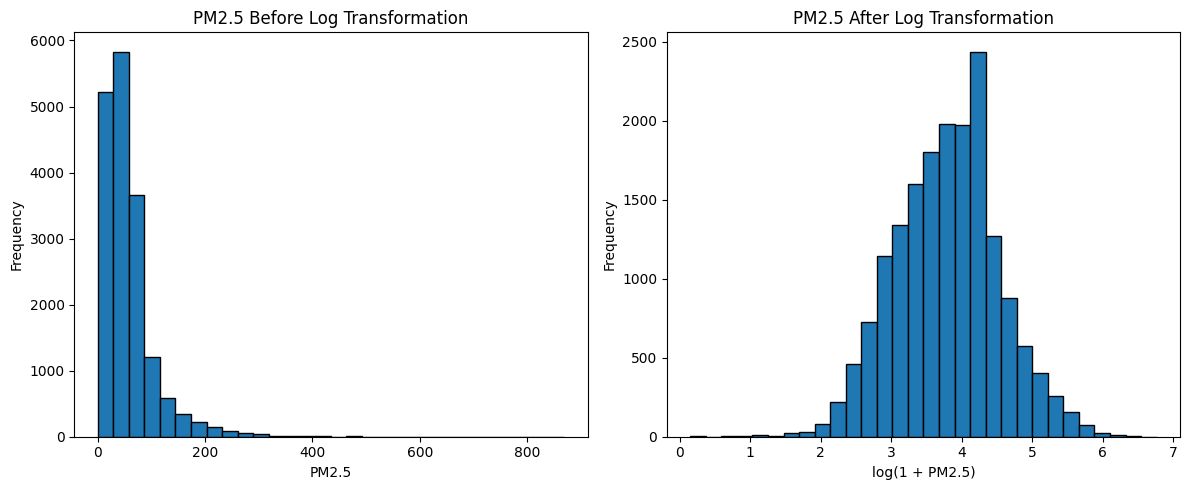

In [45]:
import numpy as np

df_model['PM2.5_log'] = np.log1p(df_model['PM2.5'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_model['PM2.5'], bins=30, edgecolor='black')
axes[0].set_title('PM2.5 Before Log Transformation')
axes[0].set_xlabel('PM2.5')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_model['PM2.5_log'], bins=30, edgecolor='black')
axes[1].set_title('PM2.5 After Log Transformation')
axes[1].set_xlabel('log(1 + PM2.5)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The logarithmic transformation compresses the long right tail of PM2.5 and produces a more compact distribution.

However, a more symmetric distribution does not automatically mean better predictive performance. The transformed and untransformed versions will therefore be compared empirically rather than assuming that the transformation improves the model.

### 6.3 Creating a Classification Target

The project considers two machine learning tasks:

1. **Regression:** predict the continuous AQI value.
2. **Classification:** determine whether an observation represents elevated air pollution.

For the binary classification task, observations with AQI greater than 100 are labelled as `1` and the remaining observations as `0`.

This converts the continuous AQI prediction problem into a practical air-quality warning problem.


In [46]:
df_model['AQI_BadAir'] = (df_model['AQI'] > 100).astype(int)

print(df_model['AQI_BadAir'].value_counts())
print("\nClass proportions:")
print(df_model['AQI_BadAir'].value_counts(normalize=True))

AQI_BadAir
1    9765
0    7741
Name: count, dtype: int64

Class proportions:
AQI_BadAir
1    0.557809
0    0.442191
Name: proportion, dtype: float64


The class distribution is checked before training classification models because class imbalance can make accuracy misleading. Precision, recall and F1-score will therefore also be considered during model evaluation.

### 6.4 Creating an Interaction Feature

PM2.5 and PM10 are both particulate pollutants and may jointly indicate periods of severe particulate pollution.

To capture this potential combined effect, an interaction feature is created:

$$
PM_{interaction} = PM2.5 \times PM10
$$

The feature will later be compared with the original feature set to determine whether explicitly representing this interaction improves regression performance.


In [47]:
df_model['PM_interaction'] = (df_model['PM2.5'] * df_model['PM10'])

df_model[['PM2.5', 'PM10', 'PM_interaction']].head()

,PM2.5,PM10,PM_interaction
932,37.55,122.41,4596.4955
933,33.97,116.32,3951.3904
934,35.48,130.07,4614.8836
935,34.11,138.31,4717.7541
936,33.69,111.73,3764.1837


The interaction feature represents the joint magnitude of PM2.5 and PM10 concentrations. Its usefulness should be evaluated through model performance rather than assumed from its domain interpretation alone.

### 6.5 One-Hot Encoding of Season

`Season` is a categorical variable with four nominal categories: Winter, Summer, Monsoon and Post-Monsoon.

Because these categories do not have a natural numerical order, label encoding would introduce a false relationship between them.

One-hot encoding instead creates a separate binary column for each category, allowing the model to treat each season independently.

In [48]:
season_dummies = pd.get_dummies(df_model['Season']).astype(int)

df_model = pd.concat(
    [df_model.drop(columns='Season'), season_dummies],
    axis=1
)

print(df_model.head())

     PM2.5    PM10    NO2    AQI  PM2.5_log  AQI_BadAir  PM_interaction  \
932  37.55  122.41  85.12  281.0   3.651956           1       4596.4955   
933  33.97  116.32  79.71  330.0   3.554491           1       3951.3904   
934  35.48  130.07  77.61  356.0   3.596764           1       4614.8836   
935  34.11  138.31  75.23  359.0   3.558486           1       4717.7541   
936  33.69  111.73  68.90  547.0   3.546451           1       3764.1837   

     Monsoon  Post-Monsoon  Summer  Winter  
932        0             0       1       0  
933        0             0       1       0  
934        0             0       1       0  
935        0             0       1       0  
936        0             0       1       0  


The categorical `Season` variable has been converted into four binary features. Each observation receives a value of 1 for its corresponding season and 0 for the other seasons.

This representation avoids imposing an artificial ordering on the seasons.

### 6.6 Domain-Informed Features

Domain knowledge can also be used to construct interpretable binary indicators. For example, winter conditions and simultaneous high PM2.5 and PM10 concentrations may represent meaningful air-quality conditions.

These features are treated as experimental rather than automatically included in the final feature set. Their value will be determined by comparing model performance with and without them.

In [49]:
df_model['is_winter'] = (
    df.loc[df_model.index, 'Season'] == 'Winter'
).astype(int)

df_model['high_particulate'] = (
    (df_model['PM2.5'] > 100) &
    (df_model['PM10'] > 150)
).astype(int)

df_model[['is_winter', 'high_particulate']].head()

,is_winter,high_particulate
932,0,0
933,0,0
934,0,0
935,0,0
936,0,0


These features translate domain assumptions into explicit model inputs. Their usefulness will be tested rather than assumed, since a model may already be able to learn similar thresholds from the original continuous variables.

### 6.7 Final Feature Sets for Modelling

Different experiments in this section produced several possible feature representations. To keep the modelling stage interpretable, the following feature sets will be compared:

* **Base features:** PM2.5, PM10 and NO2
* **Transformed features:** PM2.5_log, PM10 and NO2
* **Interaction features:** PM2.5, PM10, NO2 and PM interaction
* **Extended features:** base features plus domain-informed indicators

The base feature set will serve as the reference point for subsequent experiments.

In [50]:
base_features = ['PM2.5', 'PM10', 'NO2']
log_features = ['PM2.5_log', 'PM10', 'NO2']
interaction_features = [
    'PM2.5',
    'PM10',
    'NO2',
    'PM_interaction'
]
extended_features = [
    'PM2.5',
    'PM10',
    'NO2',
    'is_winter',
    'high_particulate'
]

print("Base features:", base_features)
print("Log-transformed features:", log_features)
print("Interaction features:", interaction_features)
print("Extended features:", extended_features)

Base features: ['PM2.5', 'PM10', 'NO2']
Log-transformed features: ['PM2.5_log', 'PM10', 'NO2']
Interaction features: ['PM2.5', 'PM10', 'NO2', 'PM_interaction']
Extended features: ['PM2.5', 'PM10', 'NO2', 'is_winter', 'high_particulate']


### 6.8 Train-Test Split

Before fitting machine learning models, the data is divided into training and testing sets.

An 80:20 split is used, with the training set used to learn model parameters and the test set reserved for evaluating performance on unseen observations.

For the classification task, stratification is used to preserve the proportion of the two target classes in both sets. The regression task does not use stratification because its target is continuous.

In [51]:
from sklearn.model_selection import train_test_split

# Regression
X_reg = df_model[base_features]
y_reg = df_model['AQI']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification
X_cls = df_model[base_features]
y_cls = df_model['AQI_BadAir']

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    stratify=y_cls,
    random_state=42
)

print("Regression training set:", X_reg_train.shape)
print("Regression test set:", X_reg_test.shape)

print("Classification training set:", X_cls_train.shape)
print("Classification test set:", X_cls_test.shape)

Regression training set: (14004, 3)
Regression test set: (3502, 3)
Classification training set: (14004, 3)
Classification test set: (3502, 3)


The data is now prepared for modelling. The regression and classification tasks use separate target variables and appropriate train-test splitting strategies.

The modelling sections will now establish simple baselines before comparing more complex algorithms.

## 7. AQI Regression

## 8. AQI Classification

## 9. Model Evaluation

## 10. Time-Series Analysis

## 11. Key Findings

## 12. Conclusion